In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# --- Load the FINAL preprocessed classification data ---
try:
    df = pd.read_csv('preprocessed_classification_data.csv')
except FileNotFoundError:
    print("Error: 'preprocessed_classification_data.csv' not found. Please run the final pipeline notebook first.")
    exit()

In [3]:
# --- 1. Prepare Data ---
#The target variable is 'Is_High_Area'
X = df.drop('Is_High_Area', axis=1)
y = df['Is_High_Area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("--- Data Preparation Complete ---\n")

--- Data Preparation Complete ---



In [4]:
#Model 1: Default Logistic Regression
print("Training Default Logistic Regression")
default_model = LogisticRegression(random_state=42, max_iter=1000)
default_model.fit(X_train, y_train)
y_pred_default = default_model.predict(X_test)
print(f"Default Model Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Default Model F1-Score: {f1_score(y_test, y_pred_default):.4f}\n")

--- Training Default Logistic Regression ---
Default Model Accuracy: 0.7328
Default Model F1-Score: 0.7049



In [5]:
#Model 2: Tuned Logistic Regression ---
print("Training Tuned Logistic Regression")
tuned_model = LogisticRegression(random_state=42, max_iter=1000, C=0.1, solver='liblinear')
tuned_model.fit(X_train, y_train)
y_pred_tuned = tuned_model.predict(X_test)
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Model F1-Score: {f1_score(y_test, y_pred_tuned):.4f}\n")

--- Training Tuned Logistic Regression ---
Tuned Model Accuracy: 0.7237
Tuned Model F1-Score: 0.6978



In [6]:
# --- 4. Model Comparison and Visualization ---
print("--- Model Comparison ---")
if f1_score(y_test, y_pred_tuned) > f1_score(y_test, y_pred_default):
    print("Conclusion: The tuned model with stronger regularization (C=0.1) performs better.")
else:
    print("Conclusion: The default model performs better or the same.")

--- Model Comparison ---
Conclusion: The default model performs better or the same.


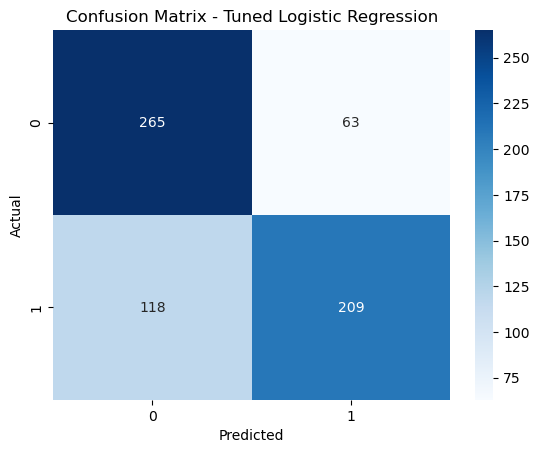

In [7]:
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()